# analysis

Загружаем три Stage-C чекпойнта (лучшие по test_mean):

| Модель | лучший loss | путь |
|---|---|---|
| USER-bge-m3 | `mse` | `./checkpoints_stageC/USER-bge-m3__mse.pt` |
| mE5-instruct | `cosent` | `./checkpoints_stageC/mE5-instruct__cosent.pt` |
| Qwen3-Emb-8B | `cosent` | `./checkpoints_stageC/Qwen3-Emb-8B__cosent.pt` |

**Что считаем:** для каждой test-пары `(s1, s2, gold)` сравниваем
- `pred_before = cos(encode_baseline(s1), encode_baseline(s2))`
- `pred_after  = cos(encode_finetuned(s1), encode_finetuned(s2))`

Нормализуем `gold` в шкалу `[-1, 1]` (`g_norm = gold/5 * 2 - 1`).  
`err = |g_norm - pred|`, `pair_delta = err_before − err_after` (положительное → починилось).

**Категоризация пар** (по двум осям):
- **gold high / low**: `gold ≥ 4` vs `gold ≤ 1`.
- **lex high / low**: Jaccard по словам `≥ 0.5` vs `< 0.5`.

Четыре бакета:
1. `high-gold, high-lex` — синонимия, лёгкие положительные пары.
2. **`high-gold, low-lex`** — семантически близкие, синтаксически разные. Главное, что должны были научить.
3. **`low-gold, high-lex`** — лексически близкие, разный смысл (отрицания, разные субъекты).
4. `low-gold, low-lex` — далёкие пары; легко.

**Что получаем на выходе:**
- Топ-5 "fixed" и top-5 "regressed" пар в каждом бакете для каждой модели.
- Per-pair CSV.
- Scatter `gold vs pred_before vs pred_after`.
- Pivot-таблица: средний RMSE по бакетам до и после.


In [ ]:
#!pip uninstall -y torch torchvision torchaudio torchao
#!pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu121
#!pip install -U "transformers>=4.40" "datasets>=2.18" "peft==0.12.0" "accelerate" "scipy" "tqdm"

In [ ]:
# 1. Install
import sys, subprocess
def pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])
try:
    import torch, transformers, datasets, peft, scipy
except Exception:
    pip("torch", "transformers>=4.40", "datasets>=2.18",
        "peft>=0.9", "accelerate", "scipy", "tqdm", "matplotlib", "pandas")


In [ ]:
# 2. Imports + config
import os, gc as _gc, json, math, random, re, warnings, time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from scipy.stats import pearsonr, spearmanr

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from peft import (LoraConfig, get_peft_model, get_peft_model_state_dict,
                  set_peft_model_state_dict, TaskType)

import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 12,
})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

# Где лежат Stage C чекпойнты
CHECKPOINT_DIR = "./"
ANALYSIS_DIR   = "./analysis_stageC"
os.makedirs(ANALYSIS_DIR, exist_ok=True)
USE_DORA = True

def free_gpu():
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize(); torch.cuda.empty_cache()


device: cuda
gpu: NVIDIA A100-SXM4-40GB


In [ ]:
# 3. Загружаем test-сеты STS-B (ru) и STS-22 (ru)

print("Loading STSBenchmark-ru (PhilipMay/stsb_multi_mt) ...")
stsb = load_dataset("PhilipMay/stsb_multi_mt", "ru")
test_stsb_pairs = [(r["sentence1"], r["sentence2"], float(r["similarity_score"]))
                   for r in stsb["test"]]
val_stsb_pairs  = [(r["sentence1"], r["sentence2"], float(r["similarity_score"]))
                   for r in stsb["dev"]]

print("Loading STS22-ru ...")
sts22 = load_dataset("mteb/sts22-crosslingual-sts", "ru")
test_sts22_pairs = [(r["sentence1"], r["sentence2"], float(r["score"]))
                    for r in sts22["test"]]

print(f"STSB test: {len(test_stsb_pairs)} pairs   val: {len(val_stsb_pairs)} pairs")
print(f"STS22 test: {len(test_sts22_pairs)} pairs")

# объединённый DataFrame для анализа
def _to_df(pairs, dataset_name):
    return pd.DataFrame({
        "s1": [p[0] for p in pairs],
        "s2": [p[1] for p in pairs],
        "gold": [p[2] for p in pairs],
        "dataset": dataset_name,
    })

df_pairs = pd.concat([
    _to_df(test_stsb_pairs,  "STSB-test"),
    _to_df(test_sts22_pairs, "STS22-test"),
], ignore_index=True)
print("Total test pairs:", len(df_pairs))
df_pairs.head()


Loading STSBenchmark-ru (PhilipMay/stsb_multi_mt) ...


Loading STS22-ru ...
STSB test: 1379 pairs   val: 1500 pairs
STS22 test: 265 pairs
Total test pairs: 1644


,s1,s2,gold,dataset
0,Девушка укладывает волосы.,Девушка расчесывает волосы.,2.5,STSB-test
1,Группа мужчин играет в футбол на пляже.,Группа мальчиков играет в футбол на пляже.,3.6,STSB-test
2,Одна женщина измеряет лодыжку другой.,Женщина измеряет лодыжку другой женщины.,5.0,STSB-test
3,Человек режет огурец.,Мужчина режет огурец.,4.2,STSB-test
4,Человек играет на арфе.,Человек играет на клавиатуре.,1.5,STSB-test


In [ ]:
# 4. STSEncoder — точная копия из Stage C (одинаковая инференс-логика)

def _detect_lora_targets(model) -> List[str]:
    names = {n for n, _ in model.named_modules()}
    if any(".q_proj" in n for n in names):
        return ["q_proj", "k_proj", "v_proj", "o_proj"]
    return ["query", "key", "value", "output.dense"]

def last_token_pool(h, attention_mask):
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return h[:, -1]
    seq_lens = attention_mask.sum(dim=1) - 1
    bs = h.size(0)
    return h[torch.arange(bs, device=h.device), seq_lens]

E5_INSTRUCT_TASK   = "Given a text, retrieve relevant passages"
QWEN_INSTRUCT_TASK = "Given a text, retrieve relevant passages"

@dataclass
class ModelSpec:
    name: str
    model_id: str
    pooling: str           # "cls" | "mean" | "last"
    prompt: str            # "none" | "e5_instruct" | "qwen_instruct"
    is_qwen: bool = False
    dtype: torch.dtype = torch.float32
    max_length: int = 192
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.1

class STSEncoder(nn.Module):
    def __init__(self, spec: ModelSpec, mode: str = "lora", use_dora: bool = True):
        super().__init__()
        self.spec = spec
        self.tokenizer = AutoTokenizer.from_pretrained(
            spec.model_id, use_fast=True,
            padding_side="left" if spec.is_qwen else "right",
            trust_remote_code=True,
        )
        kw = {"trust_remote_code": True}
        if spec.dtype != torch.float32:
            kw["torch_dtype"] = spec.dtype
        base = AutoModel.from_pretrained(spec.model_id, **kw)
        if mode == "lora":
            targets = _detect_lora_targets(base)
            cfg_kwargs = dict(r=spec.lora_r, lora_alpha=spec.lora_alpha,
                              lora_dropout=spec.lora_dropout, bias="none",
                              target_modules=targets,
                              task_type=TaskType.FEATURE_EXTRACTION)
            if use_dora:
                try: cfg = LoraConfig(**cfg_kwargs, use_dora=True)
                except TypeError: cfg = LoraConfig(**cfg_kwargs)
            else:
                cfg = LoraConfig(**cfg_kwargs)
            self.model = get_peft_model(base, cfg)
        elif mode == "frozen":
            self.model = base
            for p in self.model.parameters(): p.requires_grad = False
        else:
            self.model = base

    def _prep(self, texts):
        if self.spec.prompt == "e5_instruct":
            return [f"Instruct: {E5_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        elif self.spec.prompt == "qwen_instruct":
            return [f"Instruct: {QWEN_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        return list(texts)

    def forward(self, texts):
        texts = self._prep(texts)
        tok = self.tokenizer(texts, padding=True, truncation=True,
                             max_length=self.spec.max_length, return_tensors="pt").to(device)
        out = self.model(**tok)
        h = out.last_hidden_state
        if self.spec.pooling == "cls":
            emb = h[:, 0]
        elif self.spec.pooling == "last":
            emb = last_token_pool(h, tok["attention_mask"])
        else:
            attn = tok["attention_mask"].unsqueeze(-1).float()
            emb  = (h * attn).sum(1) / attn.sum(1).clamp(min=1e-6)
        return F.normalize(emb.float(), p=2, dim=-1)

    @torch.no_grad()
    def encode(self, texts, batch_size: int = 64, to_cpu: bool = True):
        was = self.training; self.eval()
        embs = []
        for i in range(0, len(texts), batch_size):
            e = self.forward(texts[i:i+batch_size]).detach()
            embs.append(e.cpu() if to_cpu else e)
        self.train(was)
        return torch.cat(embs, 0)

def restore(model: STSEncoder, snapshot):
    set_peft_model_state_dict(model.model, {k: v.to(device) for k, v in snapshot.items()})


In [ ]:
# 5. MODEL_SPECS + best-loss чекпойнты (точно как в Stage C)
MODEL_SPECS = {
    "USER-bge-m3": ModelSpec(
        name="USER-bge-m3", model_id="deepvk/USER-bge-m3",
        pooling="cls", prompt="none",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "mE5-instruct": ModelSpec(
        name="mE5-instruct", model_id="intfloat/multilingual-e5-large-instruct",
        pooling="mean", prompt="e5_instruct",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "Qwen3-Emb-8B": ModelSpec(
        name="Qwen3-Emb-4B", model_id="Qwen/Qwen3-Embedding-4B",
        pooling="last", prompt="qwen_instruct",
        is_qwen=True, dtype=torch.bfloat16, max_length=256,
        lora_r=16, lora_alpha=32, lora_dropout=0.05,
    ),
}

# Лучшие лоссы по test_mean из Stage C
BEST_LOSS_PER_MODEL = {
    "USER-bge-m3":  "mse",
    "mE5-instruct": "cosent",
    "Qwen3-Emb-8B": "cosent",
}

# Размеры eval-батчей (для Qwen меньше)
EVAL_BS = {"USER-bge-m3": 64, "mE5-instruct": 48, "Qwen3-Emb-8B": 24}

# Соберём паспорта прогонов
RUNS = []
for mname, loss in BEST_LOSS_PER_MODEL.items():
    RUNS.append({
        "model_name": mname,
        "loss":       loss,
        "ckpt":       os.path.join(CHECKPOINT_DIR, f"{mname}__{loss}.pt"),
        "eval_bs":    EVAL_BS[mname],
    })
for r in RUNS:
    print(f"  {r['model_name']:<14} loss={r['loss']:<8} eval_bs={r['eval_bs']:<3} ckpt={r['ckpt']}")


  USER-bge-m3    loss=mse      eval_bs=64  ckpt=./USER-bge-m3__mse.pt
  mE5-instruct   loss=cosent   eval_bs=48  ckpt=./mE5-instruct__cosent.pt
  Qwen3-Emb-8B   loss=cosent   eval_bs=24  ckpt=./Qwen3-Emb-8B__cosent.pt


In [ ]:
# 6. Encode helpers — кодируем уникальные тексты один раз
def collect_unique_texts(df: pd.DataFrame) -> List[str]:
    s = pd.concat([df["s1"], df["s2"]], ignore_index=True)
    return list(dict.fromkeys(s.tolist()))

UNIQUE_TEXTS = collect_unique_texts(df_pairs)
print("Unique texts to encode:", len(UNIQUE_TEXTS))

def encode_all(m: STSEncoder, texts: List[str], batch_size: int) -> torch.Tensor:
    return m.encode(texts, batch_size=batch_size, to_cpu=True).float()

def pair_cos(emb_map: Dict[str, torch.Tensor], s1: List[str], s2: List[str]) -> np.ndarray:
    e1 = torch.stack([emb_map[t] for t in s1])
    e2 = torch.stack([emb_map[t] for t in s2])
    sim = (e1 * e2).sum(-1).numpy()
    return sim


Unique texts to encode: 3021


In [ ]:
# 7. Кодируем все уникальные тексты тремя моделями × {baseline, finetuned}

# emb_table[(model_name, "baseline"|"finetuned")] -> dict(text -> 1D tensor)
emb_table: Dict[Tuple[str, str], Dict[str, torch.Tensor]] = {}

for run in RUNS:
    mname  = run["model_name"]
    loss   = run["loss"]
    ckpt   = run["ckpt"]
    eval_bs= run["eval_bs"]
    spec   = MODEL_SPECS[mname]

    # 7.1 baseline (frozen, no LoRA)
    print(f"\n=== {mname}: BASELINE (frozen) ===")
    m = STSEncoder(spec, mode="frozen", use_dora=False).to(device)
    emb = encode_all(m, UNIQUE_TEXTS, batch_size=eval_bs)
    emb_table[(mname, "baseline")] = {t: emb[i].clone() for i, t in enumerate(UNIQUE_TEXTS)}
    del m, emb; free_gpu()

    # 7.2 finetuned (LoRA+DoRA, restore best ckpt)
    if not os.path.exists(ckpt):
        print(f"  !! ckpt missing: {ckpt} — пропускаем finetuned для {mname}")
        emb_table[(mname, "finetuned")] = None
        continue
    print(f"=== {mname}: FINETUNED ({loss}) <- {ckpt} ===")
    m = STSEncoder(spec, mode="lora", use_dora=USE_DORA).to(device)
    blob = torch.load(ckpt, map_location="cpu")
    restore(m, blob["state_dict"])
    m.eval()
    emb = encode_all(m, UNIQUE_TEXTS, batch_size=eval_bs)
    emb_table[(mname, "finetuned")] = {t: emb[i].clone() for i, t in enumerate(UNIQUE_TEXTS)}
    del m, emb, blob; free_gpu()

print("\nEncoded:", [(k[0], k[1], "OK" if v is not None else "MISSING")
                    for k, v in emb_table.items()])



=== USER-bge-m3: BASELINE (frozen) ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

=== USER-bge-m3: FINETUNED (mse) <- ./USER-bge-m3__mse.pt ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


=== mE5-instruct: BASELINE (frozen) ===


...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

=== Qwen3-Emb-8B: FINETUNED (cosent) <- ./Qwen3-Emb-8B__cosent.pt ===


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


Encoded: [('USER-bge-m3', 'baseline', 'OK'), ('USER-bge-m3', 'finetuned', 'OK'), ('mE5-instruct', 'baseline', 'OK'), ('mE5-instruct', 'finetuned', 'OK'), ('Qwen3-Emb-8B', 'baseline', 'OK'), ('Qwen3-Emb-8B', 'finetuned', 'OK')]


In [ ]:
# 8. Per-pair predictions, errors and pair_delta

def gold_to_norm(gold: float) -> float:
    # Шкала STSB/STS22: gold in [0, 5]  ->  [-1, 1] (как косинус)
    return float(gold) / 5.0 * 2.0 - 1.0

df_pairs["g_norm"] = df_pairs["gold"].map(gold_to_norm)

# Лексическое сходство (Jaccard по словам) — для категоризации
_WORD_RE = re.compile(r"\w+", re.UNICODE)
def jaccard_words(a: str, b: str) -> float:
    A = set(w.lower() for w in _WORD_RE.findall(a or ""))
    B = set(w.lower() for w in _WORD_RE.findall(b or ""))
    if not A or not B: return 0.0
    return len(A & B) / len(A | B)

df_pairs["lex"] = [jaccard_words(s1, s2) for s1, s2 in zip(df_pairs["s1"], df_pairs["s2"])]

# Категория пары
def categorize(gold: float, lex: float) -> str:
    g_hi  = gold >= 4.0
    g_lo  = gold <= 2.0
    l_hi  = lex  >= 0.5
    l_lo  = lex  <  0.5
    if g_hi and l_hi: return "high-gold,high-lex"
    if g_hi and l_lo: return "high-gold,low-lex"      # семантика: близко по смыслу, далеко по словам
    if g_lo and l_hi: return "low-gold,high-lex"      # обман: лексика та же, смысл разный
    if g_lo and l_lo: return "low-gold,low-lex"
    return "mid"
df_pairs["category"] = [categorize(g, l) for g, l in zip(df_pairs["gold"], df_pairs["lex"])]

# Заполняем pred_before/pred_after для каждой модели
for run in RUNS:
    mname = run["model_name"]
    base_map = emb_table.get((mname, "baseline"))
    ft_map   = emb_table.get((mname, "finetuned"))
    if base_map is None: continue
    pb = pair_cos(base_map, df_pairs["s1"].tolist(), df_pairs["s2"].tolist())
    df_pairs[f"pred_before__{mname}"] = pb
    df_pairs[f"err_before__{mname}"]  = np.abs(df_pairs["g_norm"].values - pb)
    if ft_map is not None:
        pa = pair_cos(ft_map, df_pairs["s1"].tolist(), df_pairs["s2"].tolist())
        df_pairs[f"pred_after__{mname}"] = pa
        df_pairs[f"err_after__{mname}"]  = np.abs(df_pairs["g_norm"].values - pa)
        df_pairs[f"pair_delta__{mname}"] = (df_pairs[f"err_before__{mname}"]
                                            - df_pairs[f"err_after__{mname}"])

# Сохраняем CSV
out_csv = os.path.join(ANALYSIS_DIR, "per_pair_analysis.csv")
df_pairs.to_csv(out_csv, index=False)
print(f"Saved per-pair CSV -> {out_csv}")
df_pairs.head(3).T


Saved per-pair CSV -> ./analysis_stageC/per_pair_analysis.csv


,0,1,2
s1,Девушка укладывает волосы.,Группа мужчин играет в футбол на пляже.,Одна женщина измеряет лодыжку другой.
s2,Девушка расчесывает волосы.,Группа мальчиков играет в футбол на пляже.,Женщина измеряет лодыжку другой женщины.
gold,2.5,3.6,5.0
dataset,STSB-test,STSB-test,STSB-test
g_norm,0.0,0.44,1.0
lex,0.5,0.75,0.666667
category,mid,mid,"high-gold,high-lex"
pred_before__USER-bge-m3,0.857625,0.922805,0.972459
err_before__USER-bge-m3,0.857625,0.482805,0.027541
pred_after__USER-bge-m3,0.894925,0.941003,0.978872


In [ ]:
# 9. Sanity-check: общие STS-метрики (должны совпасть со Stage C тестом)

def sts_quality(gold, pred):
    p = pearsonr(gold, pred).statistic
    s = spearmanr(gold, pred).statistic
    return p, s, (p + s) / 2.0

rows = []
for run in RUNS:
    mname = run["model_name"]
    for ds in ["STSB-test", "STS22-test"]:
        sub = df_pairs[df_pairs["dataset"] == ds]
        gold = sub["gold"].values
        for tag in ["before", "after"]:
            col = f"pred_{tag}__{mname}"
            if col not in sub.columns: continue
            pred = sub[col].values
            p, s, q = sts_quality(gold, pred)
            rows.append({"model": mname, "dataset": ds, "stage": tag,
                         "pearson": p, "spearman": s, "quality": q,
                         "n": int(len(sub))})

df_metrics = pd.DataFrame(rows)
pd.set_option("display.precision", 4)
print(df_metrics.to_string(index=False))
df_metrics.to_csv(os.path.join(ANALYSIS_DIR, "sts_metrics_recheck.csv"), index=False)


       model    dataset  stage  pearson  spearman  quality    n
 USER-bge-m3  STSB-test before   0.8269    0.8296   0.8282 1379
 USER-bge-m3  STSB-test  after   0.8498    0.8550   0.8524 1379
 USER-bge-m3 STS22-test before   0.6697    0.6829   0.6763  265
 USER-bge-m3 STS22-test  after   0.6758    0.6917   0.6837  265
mE5-instruct  STSB-test before   0.8424    0.8448   0.8436 1379
mE5-instruct  STSB-test  after   0.8509    0.8594   0.8551 1379
mE5-instruct STS22-test before   0.6434    0.6797   0.6615  265
mE5-instruct STS22-test  after   0.6919    0.7091   0.7005  265
Qwen3-Emb-8B  STSB-test before   0.8549    0.8476   0.8512 1379
Qwen3-Emb-8B  STSB-test  after   0.8880    0.8906   0.8893 1379
Qwen3-Emb-8B STS22-test before   0.6766    0.6836   0.6801  265
Qwen3-Emb-8B STS22-test  after   0.6858    0.7014   0.6936  265


In [ ]:
# 10. Сводка по 4 бакетам: средняя ошибка до/после, число пар, средняя дельта

CATEGORIES_ORDER = [
    "high-gold,high-lex",
    "high-gold,low-lex",
    "low-gold,high-lex",
    "low-gold,low-lex",
    "mid",
]

def bucket_summary(model_name: str) -> pd.DataFrame:
    col_b = f"err_before__{model_name}"
    col_a = f"err_after__{model_name}"
    if col_a not in df_pairs.columns or col_b not in df_pairs.columns:
        return pd.DataFrame()
    rows = []
    for cat in CATEGORIES_ORDER:
        sub = df_pairs[df_pairs["category"] == cat]
        if len(sub) == 0:
            rows.append({"category": cat, "n": 0,
                         "mean_err_before": np.nan, "mean_err_after": np.nan,
                         "mean_delta": np.nan,
                         "share_improved": np.nan,
                         "mean_lex": np.nan, "mean_gold": np.nan})
            continue
        rows.append({
            "category":        cat,
            "n":               int(len(sub)),
            "mean_err_before": float(sub[col_b].mean()),
            "mean_err_after":  float(sub[col_a].mean()),
            "mean_delta":      float((sub[col_b] - sub[col_a]).mean()),
            "share_improved":  float(((sub[col_b] - sub[col_a]) > 0).mean()),
            "mean_lex":        float(sub["lex"].mean()),
            "mean_gold":       float(sub["gold"].mean()),
        })
    return pd.DataFrame(rows)

bucket_dfs = {}
for run in RUNS:
    mname = run["model_name"]
    bdf = bucket_summary(mname)
    if bdf.empty: continue
    bdf.insert(0, "model", mname)
    bucket_dfs[mname] = bdf
    print(f"\n=== {mname}: ошибка по бакетам (gold ∈ [0,5], cos ∈ [-1,1], err = |g_norm - cos|) ===")
    print(bdf.to_string(index=False))

if bucket_dfs:
    df_bucket = pd.concat(bucket_dfs.values(), ignore_index=True)
    df_bucket.to_csv(os.path.join(ANALYSIS_DIR, "bucket_summary.csv"), index=False)
    print(f"\nSaved -> {os.path.join(ANALYSIS_DIR, 'bucket_summary.csv')}")



=== USER-bge-m3: ошибка по бакетам (gold ∈ [0,5], cos ∈ [-1,1], err = |g_norm - cos|) ===
      model           category   n  mean_err_before  mean_err_after  mean_delta  share_improved  mean_lex  mean_gold
USER-bge-m3 high-gold,high-lex 145           0.1375          0.1487     -0.0112          0.3586    0.6962     4.5782
USER-bge-m3  high-gold,low-lex 237           0.1655          0.1921     -0.0267          0.2743    0.2676     4.3290
USER-bge-m3  low-gold,high-lex  22           1.0754          1.1259     -0.0505          0.0455    0.5783     1.6091
USER-bge-m3   low-gold,low-lex 685           1.1161          1.2225     -0.1065          0.0073    0.1405     1.0783
USER-bge-m3                mid 555           0.5311          0.6057     -0.0746          0.0144    0.2877     3.0838

=== mE5-instruct: ошибка по бакетам (gold ∈ [0,5], cos ∈ [-1,1], err = |g_norm - cos|) ===
       model           category   n  mean_err_before  mean_err_after  mean_delta  share_improved  mean_lex  mean_go

In [ ]:
# 11. Топ-5 примеров: где модель «починилась» и где «сломалась», по бакетам

def _fmt_text(t: str, w: int = 88) -> str:
    t = (t or "").replace("\n", " ").strip()
    if len(t) > w: t = t[:w-1] + "…"
    return t

def show_top_pairs(model_name: str, category: str, k: int = 5):
    delta_col = f"pair_delta__{model_name}"
    pb_col    = f"pred_before__{model_name}"
    pa_col    = f"pred_after__{model_name}"
    eb_col    = f"err_before__{model_name}"
    ea_col    = f"err_after__{model_name}"
    if delta_col not in df_pairs.columns: return
    sub = df_pairs[df_pairs["category"] == category].copy()
    if len(sub) == 0:
        print(f"  [{category}] нет пар"); return

    fixed = sub.sort_values(delta_col, ascending=False).head(k)
    regr  = sub.sort_values(delta_col, ascending=True ).head(k)

    print(f"\n--- {model_name} / {category} : TOP-{k} FIXED (errBefore→errAfter, Δerr) ---")
    for _, r in fixed.iterrows():
        print(f"  [{r['dataset']}] gold={r['gold']:.2f}  lex={r['lex']:.2f}")
        print(f"     before: pred={r[pb_col]:+.3f} (err={r[eb_col]:.3f})")
        print(f"     after : pred={r[pa_col]:+.3f} (err={r[ea_col]:.3f})  Δerr={r[delta_col]:+.3f}")
        print(f"     s1: {_fmt_text(r['s1'])}")
        print(f"     s2: {_fmt_text(r['s2'])}")

    print(f"\n--- {model_name} / {category} : TOP-{k} REGRESSED ---")
    for _, r in regr.iterrows():
        print(f"  [{r['dataset']}] gold={r['gold']:.2f}  lex={r['lex']:.2f}")
        print(f"     before: pred={r[pb_col]:+.3f} (err={r[eb_col]:.3f})")
        print(f"     after : pred={r[pa_col]:+.3f} (err={r[ea_col]:.3f})  Δerr={r[delta_col]:+.3f}")
        print(f"     s1: {_fmt_text(r['s1'])}")
        print(f"     s2: {_fmt_text(r['s2'])}")

# Печатаем для всех моделей × всех содержательных бакетов
INTERESTING = ["high-gold,low-lex", "low-gold,high-lex",
               "high-gold,high-lex", "low-gold,low-lex"]
for run in RUNS:
    mname = run["model_name"]
    print(f"\n\n{'#'*80}\n# {mname}  (best loss = {run['loss']})\n{'#'*80}")
    for cat in INTERESTING:
        show_top_pairs(mname, cat, k=5)




################################################################################
# USER-bge-m3  (best loss = mse)
################################################################################

--- USER-bge-m3 / high-gold,low-lex : TOP-5 FIXED (errBefore→errAfter, Δerr) ---
  [STS22-test] gold=4.00  lex=0.03
     before: pred=+0.375 (err=0.225)
     after : pred=+0.573 (err=0.027)  Δerr=+0.198
     s1: Фото: портал мэра и правительства Москвы  Специальная праздничная программа ждет гостей…
     s2: 18+ © 2019 AO Редакция газеты «Вечерняя Москва» Эл №ФС77-69371. Роскомнадзор.  Коммента…
  [STS22-test] gold=4.00  lex=0.03
     before: pred=+0.325 (err=0.275)
     after : pred=+0.520 (err=0.080)  Δerr=+0.194
     s1: СМИ: Россия сможет обслуживать внешний долг без лицензии США  Решение США не продлевать…
     s2: Российский боец смешанного стиля (MMA) Алексей Олейник одержал победу над бразильцем Фа…
  [STS22-test] gold=4.00  lex=0.05
     before: pred=+0.331 (err=0.269)
     after : 

In [ ]:
from IPython.display import display, HTML

def show_clean_top_fixed(model_name: str, categories: list, k: int = 5):
    delta_col = f"pair_delta__{model_name}"
    pb_col    = f"pred_before__{model_name}"
    pa_col    = f"pred_after__{model_name}"

    if delta_col not in df_pairs.columns:
        return

    for cat in categories:
        sub = df_pairs[df_pairs["category"] == cat].copy()
        if len(sub) == 0:
            print(f"\n--- {model_name} / {cat} : No pairs found ---")
            continue

        # Get Top-K Fixed (highest positive delta)
        fixed = sub.sort_values(delta_col, ascending=False).head(k)

        # Select and rename columns for the requested 6-column view
        table = fixed[["s1", "s2", "gold", "lex", pb_col, pa_col]].copy()
        table.columns = ["s1", "s2", "gold", "lex", "before", "after"]

        print(f"\n### {model_name} | Category: {cat} | TOP-{k} FIXED")
        # Use display(HTML(...)) for better text wrapping in Colab
        display(HTML(table.to_html(index=False)))

# Focus categories requested by user
TARGET_CATS = ["high-gold,low-lex", "low-gold,high-lex"]

for run in RUNS:
    mname = run["model_name"]
    show_clean_top_fixed(mname, TARGET_CATS, k=5)


### USER-bge-m3 | Category: high-gold,low-lex | TOP-5 FIXED



### USER-bge-m3 | Category: low-gold,high-lex | TOP-5 FIXED


s1,s2,gold,lex,before,after
Кто-то рисует.,Кто-то танцует.,0.3,0.5,0.6188,0.5838
"""Кризис среднего возраста: как помочь себе и близким"" Вышла в свет такая вот замечательная книга на одну из центральных тем этого блога - кризис среднего возраста. Сразу хочу поблагодарить двух…\n\n""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"" ""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"". * * * Соционика: 16 ключей к человеку Ни одно…\n\n""Философский фреш"" Итак. Вышла в свет эпическая книга ""Философский фреш"". Текст - мой, иллюстрации - замечательной художницы maxima_for, которую хорошо…\n\n""Наше странное кино"" Как известно, два лучших киноблогера современности - это Евгений Васильев (известный в жж как zheniavasilievv) и Елена Комиссарова…\n\nЛучшие киноэпизоды. Эпизод с котиком из фильма ""Мюнхен"" Ударная доза позитива (нет):\n\nКуда и зачем Иван запустил дубинки в фильме ""Морозко"" Иван в фильме ""Морозко"" до определенного момента маялся бессмысленной дурью в своей деревне, но потом решил отправиться в так называемое Путешествие…\n\nЛучшие киноэпизоды. Эпизод с нацисткой из фильма ""Кролик Джоджо"" В новой рубрике ""Лучшие киноэпизоды"" буду разбирать самые сильные моменты из фильмов последних лет. Начну с эпизода из фильма ""Кролик Джоджо"":\n\nПрекрасное В своё время я, mage_pro и rtr_brainz составили топ-7 самых красивых квнщиц. В моём топ-7 (…","""Кризис среднего возраста: как помочь себе и близким"" Вышла в свет такая вот замечательная книга на одну из центральных тем этого блога - кризис среднего возраста. Сразу хочу поблагодарить двух…\n\n""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"" ""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"". * * * Соционика: 16 ключей к человеку Ни одно…\n\n""Философский фреш"" Итак. Вышла в свет эпическая книга ""Философский фреш"". Текст - мой, иллюстрации - замечательной художницы maxima_for, которую хорошо…\n\n""Наше странное кино"" Как известно, два лучших киноблогера современности - это Евгений Васильев (известный в жж как zheniavasilievv) и Елена Комиссарова…\n\nЛучшие киноэпизоды. Эпизод с котиком из фильма ""Мюнхен"" Ударная доза позитива (нет):\n\nКуда и зачем Иван запустил дубинки в фильме ""Морозко"" Иван в фильме ""Морозко"" до определенного момента маялся бессмысленной дурью в своей деревне, но потом решил отправиться в так называемое Путешествие…\n\nЛучшие киноэпизоды. Эпизод с нацисткой из фильма ""Кролик Джоджо"" В новой рубрике ""Лучшие киноэпизоды"" буду разбирать самые сильные моменты из фильмов последних лет. Начну с эпизода из фильма ""Кролик Джоджо"":\n\nПрекрасное В своё время я, mage_pro и rtr_brainz составили топ-7 самых красивых квнщиц. В моём топ-7 (…",1.0,1.0,1.0000,1.0000
Человек играет на гитаре.,Человек играет на клавиатуре.,1.8,0.6,0.6487,0.6518
Человек играет на флейте.,Человек играет на гитаре.,2.0,0.6,0.7249,0.7307
Человек играет на пианино.,Человек играет на скрипке.,2.0,0.6,0.7536,0.7669



### mE5-instruct | Category: high-gold,low-lex | TOP-5 FIXED



### mE5-instruct | Category: low-gold,high-lex | TOP-5 FIXED


s1,s2,gold,lex,before,after
Кто-то рисует.,Кто-то танцует.,0.3,0.5,0.8746,0.7033
Мужчина режет помидор.,Мужчина режет булочку.,2.0,0.5,0.8845,0.7690
Заголовки основных иранских газет 14 декабря,Заголовки основных иранских газет 29 июля,2.0,0.5,0.9388,0.8248
Человек играет на флейте.,Человек играет на гитаре.,2.0,0.6,0.9245,0.8176
Человек играет на гитаре.,Человек играет на клавиатуре.,1.8,0.6,0.9016,0.8030



### Qwen3-Emb-8B | Category: high-gold,low-lex | TOP-5 FIXED


s1,s2,gold,lex,before,after
"Еще несколько моментов, о которых стоит подумать:",Есть о чем подумать:,5.0,0.2222,0.7316,0.9447
"СМИ: Россия сможет обслуживать внешний долг без лицензии США\n\nРешение США не продлевать лицензию, разрешавшую обслуживание гособлигаций России в долларах, повысило риск дефолта, однако остались сохранены условия, благодаря которым у России есть все шансы избежать такого сценария.\n\nВ документации всех российских выпусков обнаруживается условие «Возмещение в другой валюте» (Currency Indemnity), и оно теоретически открывает способ для платежей в рублях без оснований объявить российский дефолт. Оно независимо от другого условия «Выплата в альтернативных валютах» (Alternative Payment Currency), которое содержится в бумагах, выпущенных с 2018 года, и допускает законные выплаты в рублях, если, к примеру, санкции препятствуют платежу в оригинальной валюте, пишет РБК.\n\nЭто означает, что если Россия платит держателю в валюте, отличной от доллара, то платежное обязательство будет считаться выполненным, если инвестор в ближайший возможный день сможет обменять полученное количество другой валюты на доллары в актуальном размере. При этом, если же при конвертации сумма в долларах будет меньше за счет действующего курса, то Россия обязана возместить эту недостачу держателю, а также компенсировать ему все транзакционные издержки.\n\nКак пояснила глава отдела политических рисков консалтинговой компании Hawthorn Advisors Максимилиан Хесс, Россия сможет доказать отсутствие дефолта, если иностранные держатели ее бумаг действительно смогут обменять полученные рубли на доллары.\n\nПрофессор Школы права Университета Вирджинии, исследователь суверенных долгов Миту Гулати подтвердил, что такое «хитрое» условие действительно потенциально позволяет России выполнить свои обязательства по бондам даже через рублевые выплаты.\n\nУточняется, что без лицензии США американские инвесторы не имеют права проводить транзакции с Минфином России, то есть при новом способе выплат не смогут ничего сделать с полученными рублями. Однако неамериканские инвесторы (которых большинство) смогут в теории получить рубли и обменять их на доллары через НРД, в этом случае у них не будет оснований заявлять о дефолте.\n\nНесмотря на это, Хесс допускает, что Международная ассоциация по свопам и деривативам (ISDA, регулирует выплаты финансовых инструментов, страхующих инвесторов от дефолтов эмитентов) или кредитно-рейтинговые агентства все равно признают российский дефолт, если Минфин осуществит выплаты нерезидентам в рублях, поскольку «есть проблемы с конвертируемостью рубля».\n\nРанее Минфин США заявил, что срок действия американской генеральной лицензии, позволяющей России производить выплаты для обслуживания своего внешнего долга, решено не продлевать после 25 мая.\n\nМежду тем России 27 мая предстоит платеж по еврооблигациям.\n\nВ конце апреля Минфин России заявлял, что исполнил в долларах обязательства по суверенным еврооблигациям с погашением в 2022 и 2042 годах. В мае СМИ сообщили, что американский Минфин аннулирует действие так называемой генеральной лицензии, исключающей из-под антироссийских санкций выплаты по обслуживанию части суверенного долга России. Однако даже сам Минфин США признает, что наступление технического дефолта в России не изменит в корне ситуацию, так как страна в условиях санкций все равно не имеет доступ к мировому рынку капитала.\n\nСмотрите ещё больше видео на YouTube-канале ВЗГЛЯД","Фото: Кирилл Зыков / АГН «Москва»\n\nМинтруд РФ получил проект о сокращении новогодних праздников в 2021 году. Нерабочие дни в январе определены Трудовым кодексом, изменения в него нужно обсуждать с социальными партнерами. Об этом во вторник, 16 июня, сообщили в пресс-службе министерства.\n\nГлава экономического комитета Совета Федерации Андрей Кутепов ранее направил в Минтруд на отзыв законопроект о сокращении новогодних праздников до трех дней, с 1 по 3 января. По его словам, это позволит компенсировать действовавшие из-за пандемии коронавир


### Qwen3-Emb-8B | Category: low-gold,high-lex | TOP-5 FIXED


s1,s2,gold,lex,before,after
"""Кризис среднего возраста: как помочь себе и близким"" Вышла в свет такая вот замечательная книга на одну из центральных тем этого блога - кризис среднего возраста. Сразу хочу поблагодарить двух…\n\n""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"" ""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"". * * * Соционика: 16 ключей к человеку Ни одно…\n\n""Философский фреш"" Итак. Вышла в свет эпическая книга ""Философский фреш"". Текст - мой, иллюстрации - замечательной художницы maxima_for, которую хорошо…\n\n""Наше странное кино"" Как известно, два лучших киноблогера современности - это Евгений Васильев (известный в жж как zheniavasilievv) и Елена Комиссарова…\n\nЛучшие киноэпизоды. Эпизод с котиком из фильма ""Мюнхен"" Ударная доза позитива (нет):\n\nКуда и зачем Иван запустил дубинки в фильме ""Морозко"" Иван в фильме ""Морозко"" до определенного момента маялся бессмысленной дурью в своей деревне, но потом решил отправиться в так называемое Путешествие…\n\nЛучшие киноэпизоды. Эпизод с нацисткой из фильма ""Кролик Джоджо"" В новой рубрике ""Лучшие киноэпизоды"" буду разбирать самые сильные моменты из фильмов последних лет. Начну с эпизода из фильма ""Кролик Джоджо"":\n\nПрекрасное В своё время я, mage_pro и rtr_brainz составили топ-7 самых красивых квнщиц. В моём топ-7 (…","""Кризис среднего возраста: как помочь себе и близким"" Вышла в свет такая вот замечательная книга на одну из центральных тем этого блога - кризис среднего возраста. Сразу хочу поблагодарить двух…\n\n""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"" ""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"". * * * Соционика: 16 ключей к человеку Ни одно…\n\n""Философский фреш"" Итак. Вышла в свет эпическая книга ""Философский фреш"". Текст - мой, иллюстрации - замечательной художницы maxima_for, которую хорошо…\n\n""Наше странное кино"" Как известно, два лучших киноблогера современности - это Евгений Васильев (известный в жж как zheniavasilievv) и Елена Комиссарова…\n\nЛучшие киноэпизоды. Эпизод с котиком из фильма ""Мюнхен"" Ударная доза позитива (нет):\n\nКуда и зачем Иван запустил дубинки в фильме ""Морозко"" Иван в фильме ""Морозко"" до определенного момента маялся бессмысленной дурью в своей деревне, но потом решил отправиться в так называемое Путешествие…\n\nЛучшие киноэпизоды. Эпизод с нацисткой из фильма ""Кролик Джоджо"" В новой рубрике ""Лучшие киноэпизоды"" буду разбирать самые сильные моменты из фильмов последних лет. Начну с эпизода из фильма ""Кролик Джоджо"":\n\nПрекрасное В своё время я, mage_pro и rtr_brainz составили топ-7 самых красивых квнщиц. В моём топ-7 (…",1.0,1.0,1.0000,1.0000
Акции KL выше в середине дня,Акции KL снизились в середине утра,1.6,0.5,0.8416,0.9005
Черно-белая собака бежит по воде.,Черно-коричневая собака бежит по полю.,2.0,0.5,0.7687,0.8565
Удар американского беспилотника убил восемь человек в Вазиристане.,Удар американского беспилотника убил 11 в Пакистане,2.0,0.5,0.7323,0.8332
Девушка играет на гитаре.,Девушка играет на пианино.,2.0,0.6,0.7544,0.8581


In [ ]:
# 12. Топ-5 пар «по жизни» (без разбивки по бакетам), для отчёта

def overall_top(model_name: str, k: int = 5):
    delta_col = f"pair_delta__{model_name}"
    pb_col    = f"pred_before__{model_name}"
    pa_col    = f"pred_after__{model_name}"
    eb_col    = f"err_before__{model_name}"
    ea_col    = f"err_after__{model_name}"
    if delta_col not in df_pairs.columns: return None, None
    fixed = df_pairs.sort_values(delta_col, ascending=False).head(k)[
        ["dataset","gold","lex","category", pb_col, pa_col, eb_col, ea_col, delta_col, "s1","s2"]
    ].copy()
    regr  = df_pairs.sort_values(delta_col, ascending=True ).head(k)[
        ["dataset","gold","lex","category", pb_col, pa_col, eb_col, ea_col, delta_col, "s1","s2"]
    ].copy()
    return fixed, regr

for run in RUNS:
    mname = run["model_name"]
    fixed, regr = overall_top(mname, k=5)
    if fixed is None: continue
    print(f"\n========= {mname}: ОБЩИЙ TOP-5 FIXED =========")
    for _, r in fixed.iterrows():
        print(f"  [{r['dataset']:<10}] cat={r['category']:<18} gold={r['gold']:.2f} lex={r['lex']:.2f}")
        print(f"     pred: {r[f'pred_before__{mname}']:+.3f} -> {r[f'pred_after__{mname}']:+.3f}  "
              f"Δerr={r[f'pair_delta__{mname}']:+.3f}")
        print(f"     s1: {r['s1']}")
        print(f"     s2: {r['s2']}")
    print(f"\n========= {mname}: ОБЩИЙ TOP-5 REGRESSED =========")
    for _, r in regr.iterrows():
        print(f"  [{r['dataset']:<10}] cat={r['category']:<18} gold={r['gold']:.2f} lex={r['lex']:.2f}")
        print(f"     pred: {r[f'pred_before__{mname}']:+.3f} -> {r[f'pred_after__{mname}']:+.3f}  "
              f"Δerr={r[f'pair_delta__{mname}']:+.3f}")
        print(f"     s1: {r['s1']}")
        print(f"     s2: {r['s2']}")



========= USER-bge-m3: ОБЩИЙ TOP-5 FIXED =========
  [STS22-test] cat=high-gold,low-lex  gold=4.00 lex=0.03
     pred: +0.375 -> +0.573  Δerr=+0.198
     s1: Фото: портал мэра и правительства Москвы

Специальная праздничная программа ждет гостей Тверской улицы, которую сделают пешеходной 15 марта в рамках фестиваля "Крымская весна", сообщает оргкомитет цикла городских уличных фестивалей "Московские сезоны".

На главой улице столицы пройдут концерты звезд, спортивные шоу, 20 сеансов интеллектуальных игр "Что? Где? Когда?" и BrainZona и 70 мастер-классов: по современной хореографии, скульптурной лепке и чеканке сувенирных "монет".

Все мероприятия будут бесплатными. Попасть на них можно будет с 10:00 до 20:00.

Сеансы игр "Что? Где? Когда?" и BrainZona будут проходить одновременно на двух подиумах. Показать свою эрудицию смогут взрослые и дети от 12 лет. Всего за праздничный день поучаствовать в двух интеллектуальных состязаниях смогут 110 команд.

Желающих сразиться в "Что? Где? Когда?

In [ ]:
from IPython.display import display, HTML

def show_clean_top_fixed(model_name: str, categories: list, k: int = 5):
    delta_col = f"pair_delta__{model_name}"
    pb_col    = f"pred_before__{model_name}"
    pa_col    = f"pred_after__{model_name}"

    if delta_col not in df_pairs.columns:
        return

    for cat in categories:
        sub = df_pairs[df_pairs["category"] == cat].copy()
        if len(sub) == 0:
            continue

        # Сортируем по дельте (самые починившиеся)
        fixed = sub.sort_values(delta_col, ascending=False).head(k)

        # Выбираем нужные 6 столбцов
        table = fixed[["s1", "s2", "gold", "lex", pb_col, pa_col]].copy()
        table.columns = ["s1", "s2", "gold", "lex", "before", "after"]

        display(HTML(f"<h3>Model: {model_name} | Bucket: {cat} | TOP-{k} FIXED</h3>"))
        display(HTML(table.to_html(index=False)))

# Названия моделей из конфигурации
MODEL_NAMES = [r["model_name"] for r in RUNS]
TARGET_CATS = ["high-gold,low-lex", "low-gold,high-lex"]

for mname in MODEL_NAMES:
    show_clean_top_fixed(mname, TARGET_CATS, k=5)

s1,s2,gold,lex,before,after
Кто-то рисует.,Кто-то танцует.,0.3,0.5,0.6188,0.5838
"""Кризис среднего возраста: как помочь себе и близким"" Вышла в свет такая вот замечательная книга на одну из центральных тем этого блога - кризис среднего возраста. Сразу хочу поблагодарить двух…\n\n""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"" ""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"". * * * Соционика: 16 ключей к человеку Ни одно…\n\n""Философский фреш"" Итак. Вышла в свет эпическая книга ""Философский фреш"". Текст - мой, иллюстрации - замечательной художницы maxima_for, которую хорошо…\n\n""Наше странное кино"" Как известно, два лучших киноблогера современности - это Евгений Васильев (известный в жж как zheniavasilievv) и Елена Комиссарова…\n\nЛучшие киноэпизоды. Эпизод с котиком из фильма ""Мюнхен"" Ударная доза позитива (нет):\n\nКуда и зачем Иван запустил дубинки в фильме ""Морозко"" Иван в фильме ""Морозко"" до определенного момента маялся бессмысленной дурью в своей деревне, но потом решил отправиться в так называемое Путешествие…\n\nЛучшие киноэпизоды. Эпизод с нацисткой из фильма ""Кролик Джоджо"" В новой рубрике ""Лучшие киноэпизоды"" буду разбирать самые сильные моменты из фильмов последних лет. Начну с эпизода из фильма ""Кролик Джоджо"":\n\nПрекрасное В своё время я, mage_pro и rtr_brainz составили топ-7 самых красивых квнщиц. В моём топ-7 (…","""Кризис среднего возраста: как помочь себе и близким"" Вышла в свет такая вот замечательная книга на одну из центральных тем этого блога - кризис среднего возраста. Сразу хочу поблагодарить двух…\n\n""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"" ""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"". * * * Соционика: 16 ключей к человеку Ни одно…\n\n""Философский фреш"" Итак. Вышла в свет эпическая книга ""Философский фреш"". Текст - мой, иллюстрации - замечательной художницы maxima_for, которую хорошо…\n\n""Наше странное кино"" Как известно, два лучших киноблогера современности - это Евгений Васильев (известный в жж как zheniavasilievv) и Елена Комиссарова…\n\nЛучшие киноэпизоды. Эпизод с котиком из фильма ""Мюнхен"" Ударная доза позитива (нет):\n\nКуда и зачем Иван запустил дубинки в фильме ""Морозко"" Иван в фильме ""Морозко"" до определенного момента маялся бессмысленной дурью в своей деревне, но потом решил отправиться в так называемое Путешествие…\n\nЛучшие киноэпизоды. Эпизод с нацисткой из фильма ""Кролик Джоджо"" В новой рубрике ""Лучшие киноэпизоды"" буду разбирать самые сильные моменты из фильмов последних лет. Начну с эпизода из фильма ""Кролик Джоджо"":\n\nПрекрасное В своё время я, mage_pro и rtr_brainz составили топ-7 самых красивых квнщиц. В моём топ-7 (…",1.0,1.0,1.0000,1.0000
Человек играет на гитаре.,Человек играет на клавиатуре.,1.8,0.6,0.6487,0.6518
Человек играет на флейте.,Человек играет на гитаре.,2.0,0.6,0.7249,0.7307
Человек играет на пианино.,Человек играет на скрипке.,2.0,0.6,0.7536,0.7669


s1,s2,gold,lex,before,after
Кто-то рисует.,Кто-то танцует.,0.3,0.5,0.8746,0.7033
Мужчина режет помидор.,Мужчина режет булочку.,2.0,0.5,0.8845,0.7690
Заголовки основных иранских газет 14 декабря,Заголовки основных иранских газет 29 июля,2.0,0.5,0.9388,0.8248
Человек играет на флейте.,Человек играет на гитаре.,2.0,0.6,0.9245,0.8176
Человек играет на гитаре.,Человек играет на клавиатуре.,1.8,0.6,0.9016,0.8030


s1,s2,gold,lex,before,after
"Еще несколько моментов, о которых стоит подумать:",Есть о чем подумать:,5.0,0.2222,0.7316,0.9447
"СМИ: Россия сможет обслуживать внешний долг без лицензии США\n\nРешение США не продлевать лицензию, разрешавшую обслуживание гособлигаций России в долларах, повысило риск дефолта, однако остались сохранены условия, благодаря которым у России есть все шансы избежать такого сценария.\n\nВ документации всех российских выпусков обнаруживается условие «Возмещение в другой валюте» (Currency Indemnity), и оно теоретически открывает способ для платежей в рублях без оснований объявить российский дефолт. Оно независимо от другого условия «Выплата в альтернативных валютах» (Alternative Payment Currency), которое содержится в бумагах, выпущенных с 2018 года, и допускает законные выплаты в рублях, если, к примеру, санкции препятствуют платежу в оригинальной валюте, пишет РБК.\n\nЭто означает, что если Россия платит держателю в валюте, отличной от доллара, то платежное обязательство будет считаться выполненным, если инвестор в ближайший возможный день сможет обменять полученное количество другой валюты на доллары в актуальном размере. При этом, если же при конвертации сумма в долларах будет меньше за счет действующего курса, то Россия обязана возместить эту недостачу держателю, а также компенсировать ему все транзакционные издержки.\n\nКак пояснила глава отдела политических рисков консалтинговой компании Hawthorn Advisors Максимилиан Хесс, Россия сможет доказать отсутствие дефолта, если иностранные держатели ее бумаг действительно смогут обменять полученные рубли на доллары.\n\nПрофессор Школы права Университета Вирджинии, исследователь суверенных долгов Миту Гулати подтвердил, что такое «хитрое» условие действительно потенциально позволяет России выполнить свои обязательства по бондам даже через рублевые выплаты.\n\nУточняется, что без лицензии США американские инвесторы не имеют права проводить транзакции с Минфином России, то есть при новом способе выплат не смогут ничего сделать с полученными рублями. Однако неамериканские инвесторы (которых большинство) смогут в теории получить рубли и обменять их на доллары через НРД, в этом случае у них не будет оснований заявлять о дефолте.\n\nНесмотря на это, Хесс допускает, что Международная ассоциация по свопам и деривативам (ISDA, регулирует выплаты финансовых инструментов, страхующих инвесторов от дефолтов эмитентов) или кредитно-рейтинговые агентства все равно признают российский дефолт, если Минфин осуществит выплаты нерезидентам в рублях, поскольку «есть проблемы с конвертируемостью рубля».\n\nРанее Минфин США заявил, что срок действия американской генеральной лицензии, позволяющей России производить выплаты для обслуживания своего внешнего долга, решено не продлевать после 25 мая.\n\nМежду тем России 27 мая предстоит платеж по еврооблигациям.\n\nВ конце апреля Минфин России заявлял, что исполнил в долларах обязательства по суверенным еврооблигациям с погашением в 2022 и 2042 годах. В мае СМИ сообщили, что американский Минфин аннулирует действие так называемой генеральной лицензии, исключающей из-под антироссийских санкций выплаты по обслуживанию части суверенного долга России. Однако даже сам Минфин США признает, что наступление технического дефолта в России не изменит в корне ситуацию, так как страна в условиях санкций все равно не имеет доступ к мировому рынку капитала.\n\nСмотрите ещё больше видео на YouTube-канале ВЗГЛЯД","Фото: Кирилл Зыков / АГН «Москва»\n\nМинтруд РФ получил проект о сокращении новогодних праздников в 2021 году. Нерабочие дни в январе определены Трудовым кодексом, изменения в него нужно обсуждать с социальными партнерами. Об этом во вторник, 16 июня, сообщили в пресс-службе министерства.\n\nГлава экономического комитета Совета Федерации Андрей Кутепов ранее направил в Минтруд на отзыв законопроект о сокращении новогодних праздников до трех дней, с 1 по 3 января. По его словам, это позволит компенсировать действовавшие из-за пандемии коронавир

s1,s2,gold,lex,before,after
"""Кризис среднего возраста: как помочь себе и близким"" Вышла в свет такая вот замечательная книга на одну из центральных тем этого блога - кризис среднего возраста. Сразу хочу поблагодарить двух…\n\n""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"" ""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"". * * * Соционика: 16 ключей к человеку Ни одно…\n\n""Философский фреш"" Итак. Вышла в свет эпическая книга ""Философский фреш"". Текст - мой, иллюстрации - замечательной художницы maxima_for, которую хорошо…\n\n""Наше странное кино"" Как известно, два лучших киноблогера современности - это Евгений Васильев (известный в жж как zheniavasilievv) и Елена Комиссарова…\n\nЛучшие киноэпизоды. Эпизод с котиком из фильма ""Мюнхен"" Ударная доза позитива (нет):\n\nКуда и зачем Иван запустил дубинки в фильме ""Морозко"" Иван в фильме ""Морозко"" до определенного момента маялся бессмысленной дурью в своей деревне, но потом решил отправиться в так называемое Путешествие…\n\nЛучшие киноэпизоды. Эпизод с нацисткой из фильма ""Кролик Джоджо"" В новой рубрике ""Лучшие киноэпизоды"" буду разбирать самые сильные моменты из фильмов последних лет. Начну с эпизода из фильма ""Кролик Джоджо"":\n\nПрекрасное В своё время я, mage_pro и rtr_brainz составили топ-7 самых красивых квнщиц. В моём топ-7 (…","""Кризис среднего возраста: как помочь себе и близким"" Вышла в свет такая вот замечательная книга на одну из центральных тем этого блога - кризис среднего возраста. Сразу хочу поблагодарить двух…\n\n""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"" ""Соционика: 16 ключей к человеку"", ""Архетип счастья"", ""От соционики до Теории уровней"". * * * Соционика: 16 ключей к человеку Ни одно…\n\n""Философский фреш"" Итак. Вышла в свет эпическая книга ""Философский фреш"". Текст - мой, иллюстрации - замечательной художницы maxima_for, которую хорошо…\n\n""Наше странное кино"" Как известно, два лучших киноблогера современности - это Евгений Васильев (известный в жж как zheniavasilievv) и Елена Комиссарова…\n\nЛучшие киноэпизоды. Эпизод с котиком из фильма ""Мюнхен"" Ударная доза позитива (нет):\n\nКуда и зачем Иван запустил дубинки в фильме ""Морозко"" Иван в фильме ""Морозко"" до определенного момента маялся бессмысленной дурью в своей деревне, но потом решил отправиться в так называемое Путешествие…\n\nЛучшие киноэпизоды. Эпизод с нацисткой из фильма ""Кролик Джоджо"" В новой рубрике ""Лучшие киноэпизоды"" буду разбирать самые сильные моменты из фильмов последних лет. Начну с эпизода из фильма ""Кролик Джоджо"":\n\nПрекрасное В своё время я, mage_pro и rtr_brainz составили топ-7 самых красивых квнщиц. В моём топ-7 (…",1.0,1.0,1.0000,1.0000
Акции KL выше в середине дня,Акции KL снизились в середине утра,1.6,0.5,0.8416,0.9005
Черно-белая собака бежит по воде.,Черно-коричневая собака бежит по полю.,2.0,0.5,0.7687,0.8565
Удар американского беспилотника убил восемь человек в Вазиристане.,Удар американского беспилотника убил 11 в Пакистане,2.0,0.5,0.7323,0.8332
Девушка играет на гитаре.,Девушка играет на пианино.,2.0,0.6,0.7544,0.8581


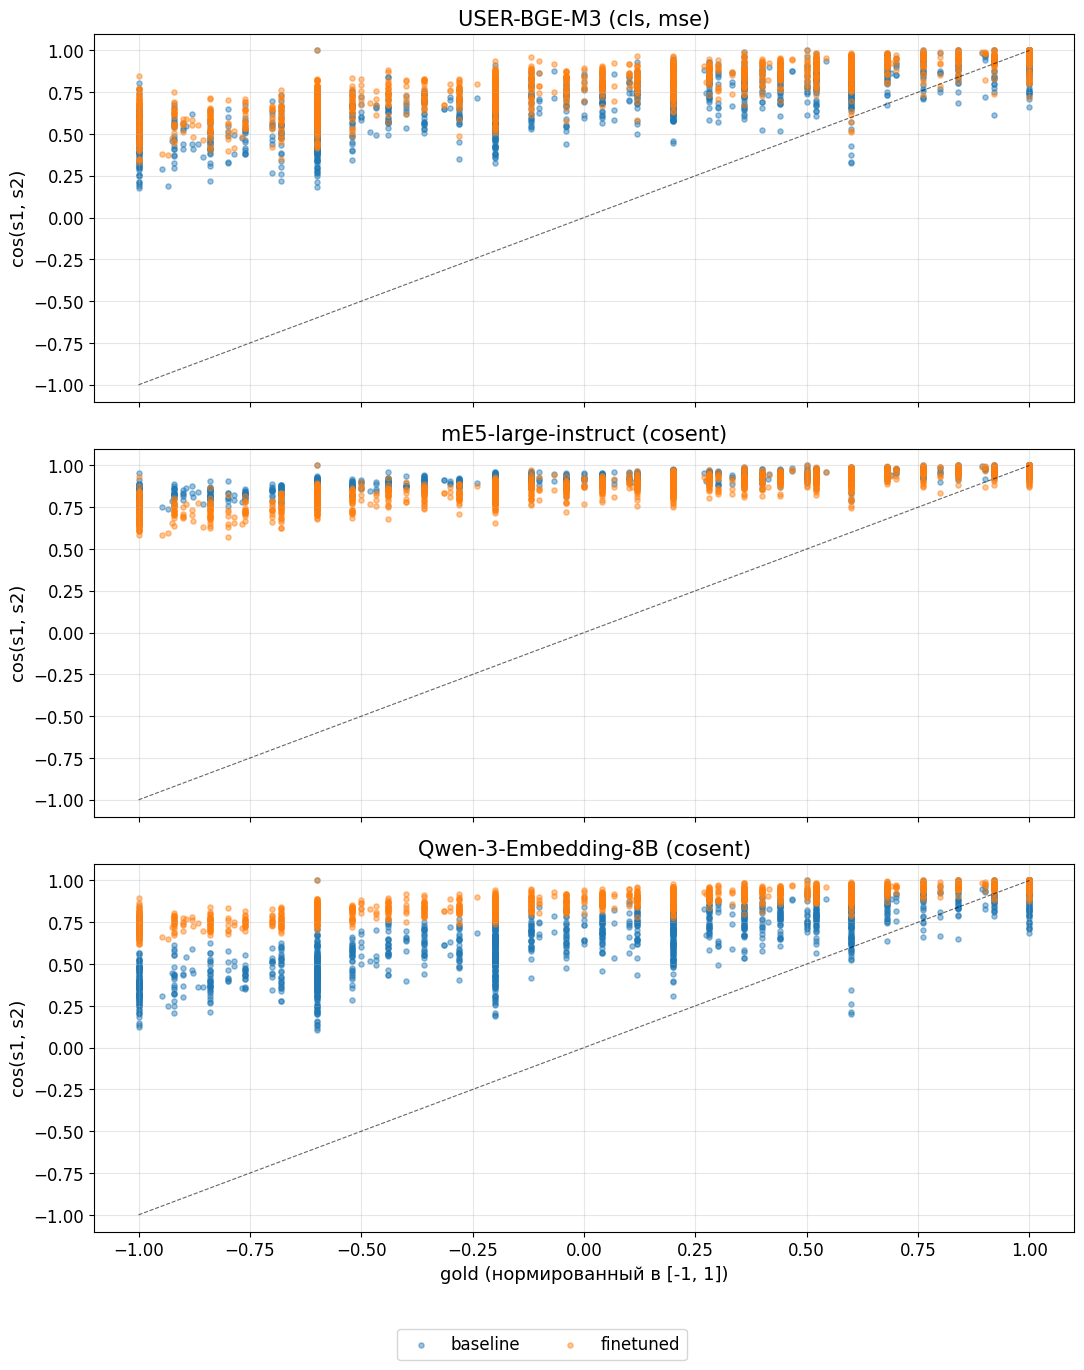

Saved: ./analysis_stageC/scatter_gold_vs_pred.png


In [ ]:
# 13. Scatter: gold vs (pred_before, pred_after) для каждой модели

MODEL_LABEL_MAP = {
    'USER-bge-m3':  'USER-BGE-M3 (cls, mse)',
    'mE5-instruct': 'mE5-large-instruct (cosent)',
    'Qwen3-Emb-8B': 'Qwen-3-Embedding-8B (cosent)',
}

n_models = sum(1 for r in RUNS if f"pred_after__{r['model_name']}" in df_pairs.columns)
fig, axes = plt.subplots(n_models, 1, figsize=(11, 4.5 * n_models), sharex=True)
if n_models == 1: axes = [axes]

i = 0
for run in RUNS:
    mname = run["model_name"]
    if f"pred_after__{mname}" not in df_pairs.columns: continue
    ax = axes[i]; i += 1
    pb = df_pairs[f"pred_before__{mname}"].values
    pa = df_pairs[f"pred_after__{mname}"].values
    g  = df_pairs["g_norm"].values
    ax.scatter(g, pb, s=14, alpha=0.45, color="tab:blue",   label="baseline")
    ax.scatter(g, pa, s=14, alpha=0.45, color="tab:orange", label="finetuned")
    ax.plot([-1, 1], [-1, 1], color="black", lw=0.8, ls="--", alpha=0.6)
    ax.set_title(MODEL_LABEL_MAP.get(mname, mname))
    ax.set_ylabel("cos(s1, s2)")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("gold (нормированный в [-1, 1])")
# одна общая легенда снизу
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.02), frameon=True)
plt.subplots_adjust(bottom=0.08, hspace=0.18)
plt.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(os.path.join(ANALYSIS_DIR, "scatter_gold_vs_pred.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(ANALYSIS_DIR, "scatter_gold_vs_pred.png"))


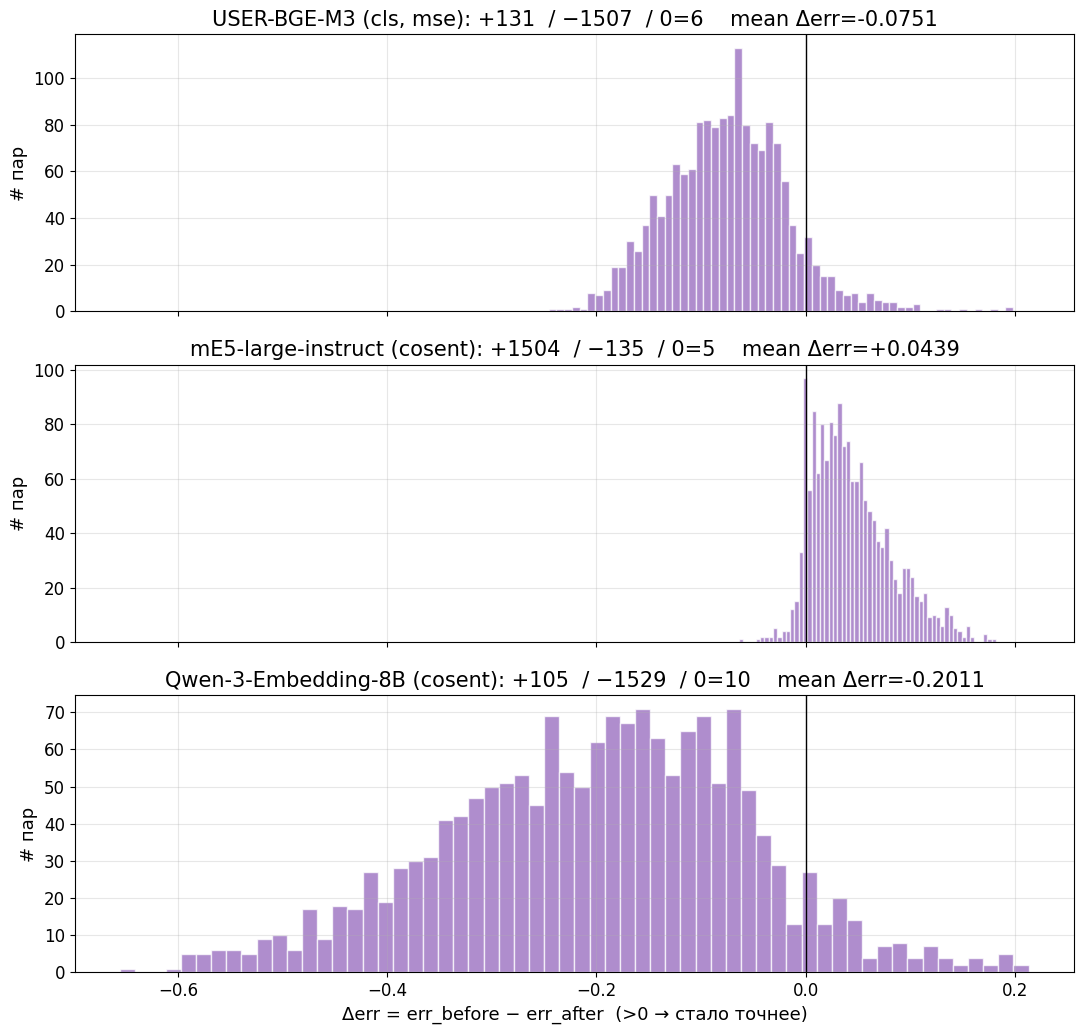

Saved: ./analysis_stageC/hist_pair_delta.png


In [ ]:
# 14. Гистограммы pair_delta — сколько пар улучшилось / ухудшилось

fig, axes = plt.subplots(n_models, 1, figsize=(11, 3.5 * n_models), sharex=True)
if n_models == 1: axes = [axes]

i = 0
for run in RUNS:
    mname = run["model_name"]
    col = f"pair_delta__{mname}"
    if col not in df_pairs.columns: continue
    ax = axes[i]; i += 1
    d = df_pairs[col].values
    ax.hist(d, bins=60, color="tab:purple", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="black", lw=1.0)
    n_pos = int((d > 0).sum()); n_neg = int((d < 0).sum()); n_z = int((d == 0).sum())
    ax.set_title(f"{MODEL_LABEL_MAP.get(mname, mname)}: "
                 f"+{n_pos}  / −{n_neg}  / 0={n_z}    mean Δerr={d.mean():+.4f}")
    ax.set_ylabel("# пар")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Δerr = err_before − err_after  (>0 → стало точнее)")
plt.tight_layout()
fig.savefig(os.path.join(ANALYSIS_DIR, "hist_pair_delta.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(ANALYSIS_DIR, "hist_pair_delta.png"))


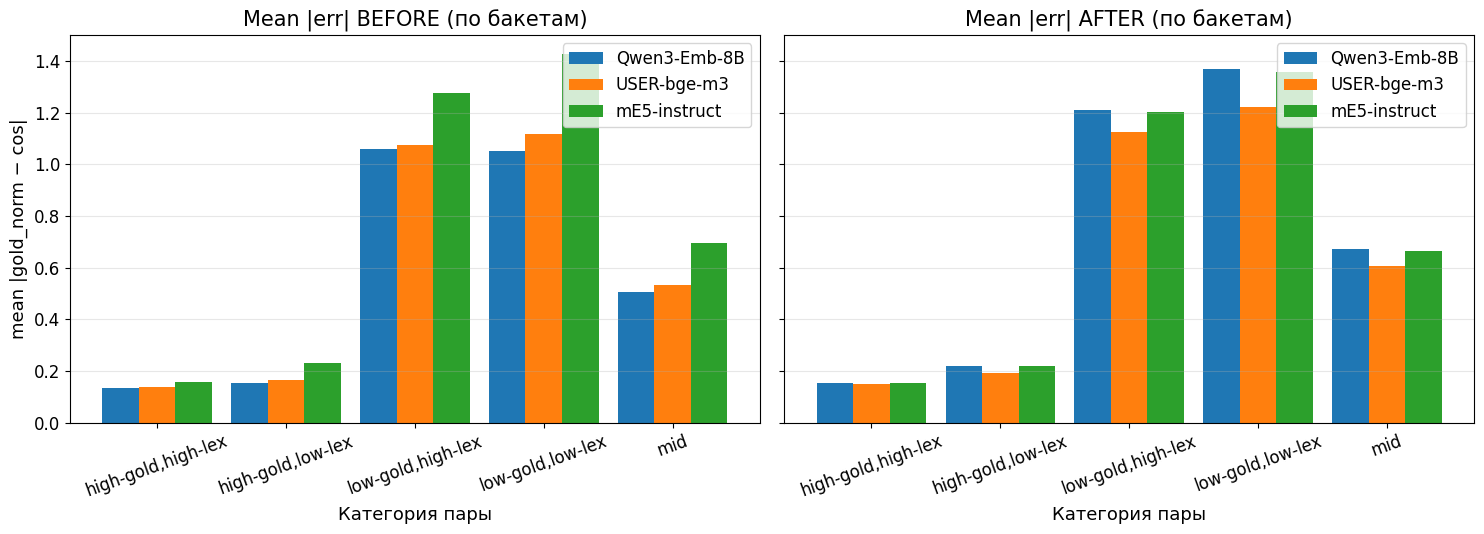

Saved: ./analysis_stageC/bucket_mean_err.png


In [ ]:
# 15. Бакет × модель — barplot среднего |err| до и после

if bucket_dfs:
    df_bucket_all = pd.concat(bucket_dfs.values(), ignore_index=True)
    pivot_b = df_bucket_all.pivot(index="category", columns="model", values="mean_err_before")
    pivot_a = df_bucket_all.pivot(index="category", columns="model", values="mean_err_after")
    pivot_b = pivot_b.reindex(CATEGORIES_ORDER)
    pivot_a = pivot_a.reindex(CATEGORIES_ORDER)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
    pivot_b.plot.bar(ax=axes[0], width=0.85)
    pivot_a.plot.bar(ax=axes[1], width=0.85)
    axes[0].set_title("Mean |err| BEFORE (по бакетам)")
    axes[1].set_title("Mean |err| AFTER (по бакетам)")
    for ax in axes:
        ax.set_xlabel("Категория пары")
        ax.set_ylabel("mean |gold_norm − cos|")
        ax.tick_params(axis='x', rotation=20)
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    fig.savefig(os.path.join(ANALYSIS_DIR, "bucket_mean_err.png"), dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", os.path.join(ANALYSIS_DIR, "bucket_mean_err.png"))
